# Problem 1: Learning Word Embeddings from IIT Jodhpur Data

**Objective:** Train Word2Vec models (CBOW and Skip-gram with Negative Sampling) on textual data collected from IIT Jodhpur sources, and analyze the semantic structure captured by the learned embeddings.

**Data Sources:**
1. IIT Jodhpur official website (Main Site Page, BTech Program Page, Curriculum Page)
2. Academic regulation documents (B.Tech, M.Sc., Ph.D)
3. Faculty profile pages
4. A few pages from the Courses Offered by CSE Dept

**Implementation:** Word2Vec models (CBOW and Skip-gram) are implemented **from scratch** using PyTorch, then compared against Gensim's reference implementation.

---

## Setup & Imports

In [2]:
# Install dependencies
!pip install requests beautifulsoup4 PyPDF2 pdfplumber gensim wordcloud matplotlib scikit-learn numpy torch tqdm -q

In [3]:
import os
import re
import time
import json
import random
import string
import warnings
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import requests
from bs4 import BeautifulSoup
import pdfplumber

import gensim
from gensim.models import Word2Vec as GensimWord2Vec

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Gensim: {gensim.__version__}")

Device: cpu
PyTorch: 2.10.0+cu128
Gensim: 4.4.0


/home/soham-khairnar/Data Visualization/dv_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Task 1: Dataset Preparation

### 1.1 Web Scraping from IIT Jodhpur Sources

We scrape text from the following IIT Jodhpur web pages:
- Main website pages (about, departments, academics, research)
- Academic regulation pages
- Faculty profiles
- Wikipedia article on IIT Jodhpur

In [4]:
# Some utility functions for web scraping and PDF text extractionn

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9",
}


def fetch_page(url, timeout=15):
    """Fetch a web page and return BeautifulSoup object."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=timeout, verify=True)
        resp.raise_for_status()
        return BeautifulSoup(resp.content, "html.parser")
    except Exception as e:
        print(f"  [WARN] Failed to fetch {url}: {e}")
        return None


def extract_text_from_soup(soup):
    """Extract clean text from BeautifulSoup, removing scripts/styles/nav."""
    if soup is None:
        return ""
    # Remove unwanted tags
    for tag in soup.find_all(["script", "style", "nav", "footer", "header",
                              "noscript", "iframe", "form", "button"]):
        tag.decompose()

    text = soup.get_text(separator=" ", strip=True)
    return text


def fetch_pdf_text_from_url(url, timeout=20):
    """Download a PDF from URL and extract text using pdfplumber."""
    try:
        resp = requests.get(url, headers=HEADERS, timeout=timeout, verify=True)
        resp.raise_for_status()
        # Save temporarily
        tmp_path = "/tmp/temp_iitj_doc.pdf"
        with open(tmp_path, "wb") as f:
            f.write(resp.content)
        text = extract_text_from_pdf(tmp_path)
        os.remove(tmp_path)
        return text
    except Exception as e:
        print(f"  [WARN] Failed to fetch PDF {url}: {e}")
        return ""


def extract_text_from_pdf(pdf_path):
    """Extract text from a local PDF file using pdfplumber."""
    text_parts = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text_parts.append(page_text)
    except Exception as e:
        print(f"  [WARN] Failed to read PDF {pdf_path}: {e}")
    return " ".join(text_parts)

In [5]:
# URLs from IIT Jodhpur Website

IITJ_WEB_URLS = [
    # Main pages
    "https://iitj.ac.in/",

    # BTech Program Web Page
    "https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology",
    
    # Department pages
    "https://www.iitj.ac.in/computer-science-engineering/",
    "https://www.iitj.ac.in/mathematics/",
    "https://www.iitj.ac.in/electrical-engineering/",

    # Curriculum Page 
    "https://iitj.ac.in/office-of-academics/en/curriculum",

    # Academics
    "https://iitj.ac.in/office-of-academics/en/academic-regulations",
    "https://iitj.ac.in/office-of-academics/en/academics",


    #Faculty Pages
    "https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://www.iitj.ac.in/People/List?dept=school-of-design&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://www.iitj.ac.in/faculty-positions/en/applicant's-qualifications",

]

print("Scraping IIT Jodhpur website pages...")
web_documents = []
for url in IITJ_WEB_URLS:
    soup = fetch_page(url)
    text = extract_text_from_soup(soup)
    if text and len(text) > 100:
        web_documents.append({"source": url, "text": text})
        print(f"  [OK] {url} — {len(text)} chars")
    else:
        print(f"  [SKIP] {url} — insufficient text")
    time.sleep(0.5)  # polite delay

print(f"\nCollected {len(web_documents)} web documents")

Scraping IIT Jodhpur website pages...
  [OK] https://iitj.ac.in/ — 3671 chars
  [OK] https://www.iitj.ac.in/Bachelor-of-Technology/en/Bachelor-of-Technology — 8211 chars
  [OK] https://www.iitj.ac.in/computer-science-engineering/ — 5125 chars
  [OK] https://www.iitj.ac.in/mathematics/ — 4803 chars
  [OK] https://www.iitj.ac.in/electrical-engineering/ — 4236 chars
  [OK] https://iitj.ac.in/office-of-academics/en/curriculum — 6548 chars
  [OK] https://iitj.ac.in/office-of-academics/en/academic-regulations — 104797 chars
  [OK] https://iitj.ac.in/office-of-academics/en/academics — 2113 chars
  [OK] https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd — 6100 chars
  [OK] https://www.iitj.ac.in/People/List?dept=school-of-design&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd — 3718 chars
  [OK] https://www.iitj.ac.in/faculty-positions/en/applicant's-qualifications — 2979 chars

Collected 11 web documents


In [6]:
# For Local PDFs

LOCAL_PDF_DIR = "pdfs"  # <-- Change this path if needed

local_pdf_documents = []
if os.path.isdir(LOCAL_PDF_DIR):
    pdf_files = [f for f in os.listdir(LOCAL_PDF_DIR) if f.lower().endswith(".pdf")]
    print(f"Found {len(pdf_files)} local PDF files in '{LOCAL_PDF_DIR}/'")
    for fname in sorted(pdf_files):
        fpath = os.path.join(LOCAL_PDF_DIR, fname)
        text = extract_text_from_pdf(fpath)
        if text and len(text) > 100:
            local_pdf_documents.append({"source": fpath, "text": text})
            print(f"  [OK] {fname} — {len(text)} chars")
        else:
            print(f"  [SKIP] {fname} — insufficient text")
else:
    print(f"No '{LOCAL_PDF_DIR}/' folder found. Skipping local PDFs.")
    print("  To include curriculum PDFs, create a 'pdfs/' folder and place them there.")

print(f"\nCollected {len(local_pdf_documents)} local PDF documents")

Found 1 local PDF files in 'pdfs/'
  [OK] CSE-Courses-Details.pdf — 24452 chars

Collected 1 local PDF documents


In [7]:
# Combining all the documents

all_documents = web_documents + local_pdf_documents

print(f"\nTotal documents collected: {len(all_documents)}")
print(f"  Web pages:        {len(web_documents)}")
print(f"  Local PDFs:       {len(local_pdf_documents)}")
print(f"  Total raw chars:  {sum(len(d['text']) for d in all_documents):,}")


Total documents collected: 12
  Web pages:        11
  Local PDFs:       1
  Total raw chars:  176,753


### 1.2 Text Preprocessing

We clean the raw scraped text through the following pipeline:
1. Remove boilerplate text and formatting artifacts (HTML remnants, URLs, emails)
2. Remove non-English text (Hindi/Devanagari characters)
3. Lowercasing
4. Tokenization (split on whitespace and punctuation)
5. Remove excessive punctuation, numbers-only tokens, and very short tokens
6. Remove standard English stopwords for the word cloud (but keep them in training corpus)

In [8]:
# Text cleaning and tokenization functions

def clean_text(text):
    """Clean raw text: remove artifacts, non-English, normalize."""
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    # Remove Devanagari / non-Latin script characters
    text = re.sub(r'[\u0900-\u097F]+', ' ', text)  # Devanagari
    text = re.sub(r'[\u0980-\u09FF]+', ' ', text)  # Bengali
    text = re.sub(r'[\u0A00-\u0A7F]+', ' ', text)  # Gurmukhi
    text = re.sub(r'[\u0A80-\u0AFF]+', ' ', text)  # Gujarati
    text = re.sub(r'[\u0B00-\u0B7F]+', ' ', text)  # Oriya
    text = re.sub(r'[\u0B80-\u0BFF]+', ' ', text)  # Tamil
    text = re.sub(r'[\u0C00-\u0C7F]+', ' ', text)  # Telugu
    text = re.sub(r'[\u0C80-\u0CFF]+', ' ', text)  # Kannada
    text = re.sub(r'[\u0D00-\u0D7F]+', ' ', text)  # Malayalam
    # Remove special characters but keep basic punctuation for sentence splitting
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\;\:\!\?\-\'\(\)]', ' ', text)
    # Remove standalone numbers (keep alphanumeric like "iit2008")
    text = re.sub(r'\b\d+\b', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text):
    """Tokenize text into words: lowercase, split, filter."""
    text = text.lower()
    # Split on whitespace and punctuation boundaries
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", text)
    # Filter: min length 2, not pure single characters
    tokens = [t for t in tokens if len(t) >= 2]
    return tokens


def text_to_sentences(text):
    """Split text into sentences, return list of token lists."""
    text = clean_text(text)
    # Split on sentence boundaries
    raw_sentences = re.split(r'[.!?;]+', text)
    sentences = []
    for sent in raw_sentences:
        tokens = tokenize(sent)
        if len(tokens) >= 3:  # skip very short sentences
            sentences.append(tokens)
    return sentences

In [9]:
# Processing all documents into sentences and tokens

all_sentences = []  # list of token lists (each sentence is a list of words)

for doc in all_documents:
    sents = text_to_sentences(doc["text"])
    all_sentences.extend(sents)

# Also create a flat token list for statistics
all_tokens = [token for sent in all_sentences for token in sent]

print(f"Total sentences: {len(all_sentences):,}")
print(f"Total tokens:    {len(all_tokens):,}")
print(f"\nSample sentences:")
for s in all_sentences[:5]:
    print(f"  {' '.join(s[:15])}{'...' if len(s)>15 else ''}")

Total sentences: 1,479
Total tokens:    23,385

Sample sentences:
  indian institute of technology jodhpur iit jodhpur redirecttologinpage
  about iit jodhpur indian institute of technology jodhpur was established in to foster technology education...
  the institute is committed to technological thought and action to benefit the economic development of...
  scholarship in teaching and learning
  scholarship in research and creative accomplishments


In [10]:
# Saving the corpus in a file

corpus_path = "corpus.txt"
with open(corpus_path, "w", encoding="utf-8") as f:
    for sent in all_sentences:
        f.write(" ".join(sent) + "\n")

print(f"Corpus written to: {corpus_path}")
print(f"  Lines (sentences): {len(all_sentences):,}")
print(f"  Total tokens:      {len(all_tokens):,}")


Corpus written to: corpus.txt
  Lines (sentences): 1,479
  Total tokens:      23,385


### 1.3 Dataset Statistics

In [11]:

# Compute and Report Dataset Statistics

word_freq = Counter(all_tokens)
vocabulary = sorted(word_freq.keys())

print("=" * 50)
print("DATASET STATISTICS")
print("=" * 50)
print(f"Total documents:        {len(all_documents)}")
print(f"Total sentences:        {len(all_sentences):,}")
print(f"Total tokens:           {len(all_tokens):,}")
print(f"Vocabulary size:        {len(vocabulary):,}")
print(f"Avg sentence length:    {np.mean([len(s) for s in all_sentences]):.1f} tokens")
print(f"Avg token length:       {np.mean([len(t) for t in all_tokens]):.1f} chars")
print(f"\nTop 20 most frequent words:")
for word, count in word_freq.most_common(20):
    print(f"  {word:<20} {count:>6}")

DATASET STATISTICS
Total documents:        12
Total sentences:        1,479
Total tokens:           23,385
Vocabulary size:        2,962
Avg sentence length:    15.8 tokens
Avg token length:       5.7 chars

Top 20 most frequent words:
  the                    1325
  of                      971
  and                     649
  to                      552
  for                     473
  in                      464
  be                      286
  will                    233
  student                 225
  on                      208
  or                      191
  by                      190
  course                  186
  is                      149
  academic                140
  students                140
  at                      138
  degree                  133
  as                      132
  with                    132


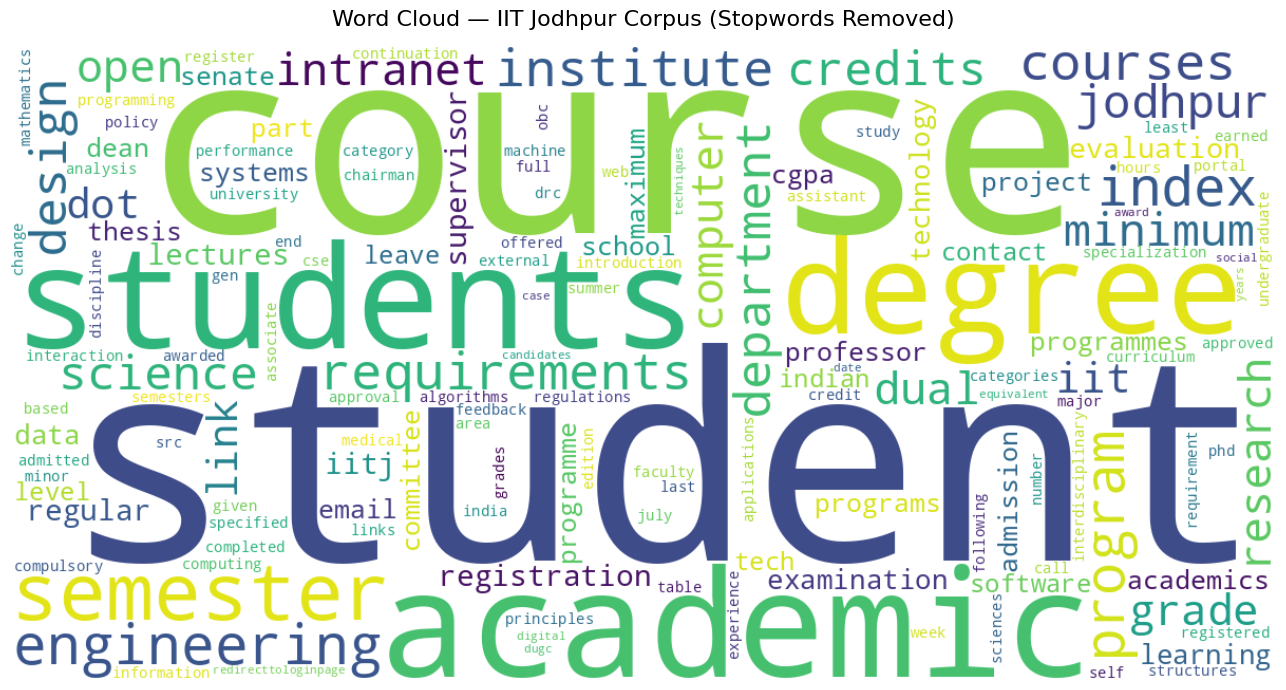

In [12]:

# Word Cloud of Most Frequent Words

# Remove common English stopwords for a more informative word cloud
STOPWORDS = set([
    "the", "be", "to", "of", "and", "in", "that", "have", "it", "for",
    "not", "on", "with", "he", "as", "you", "do", "at", "this", "but",
    "his", "by", "from", "they", "we", "say", "her", "she", "or", "an",
    "will", "my", "one", "all", "would", "there", "their", "what", "so",
    "up", "out", "if", "about", "who", "get", "which", "go", "me", "when",
    "make", "can", "like", "time", "no", "just", "him", "know", "take",
    "people", "into", "year", "your", "good", "some", "could", "them",
    "see", "other", "than", "then", "now", "look", "only", "come",
    "its", "over", "think", "also", "back", "after", "use", "two", "how",
    "our", "work", "first", "well", "way", "even", "new", "want", "because",
    "any", "these", "give", "day", "most", "us", "is", "are", "was", "were",
    "been", "being", "has", "had", "having", "does", "did", "shall", "should",
    "may", "might", "must", "need", "each", "every", "such", "more",
    "through", "during", "before", "between", "under", "above",
    "same", "per", "including", "within", "without", "however",
    "both", "while", "where", "those", "been", "upon", "should",
])

filtered_freq = {w: c for w, c in word_freq.items() if w not in STOPWORDS and len(w) > 2}

wc = WordCloud(
    width=1200, height=600,
    background_color="white",
    max_words=150,
    colormap="viridis",
    contour_width=1,
    contour_color="steelblue",
)
wc.generate_from_frequencies(filtered_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — IIT Jodhpur Corpus (Stopwords Removed)", fontsize=16, pad=15)
plt.tight_layout()
plt.show()

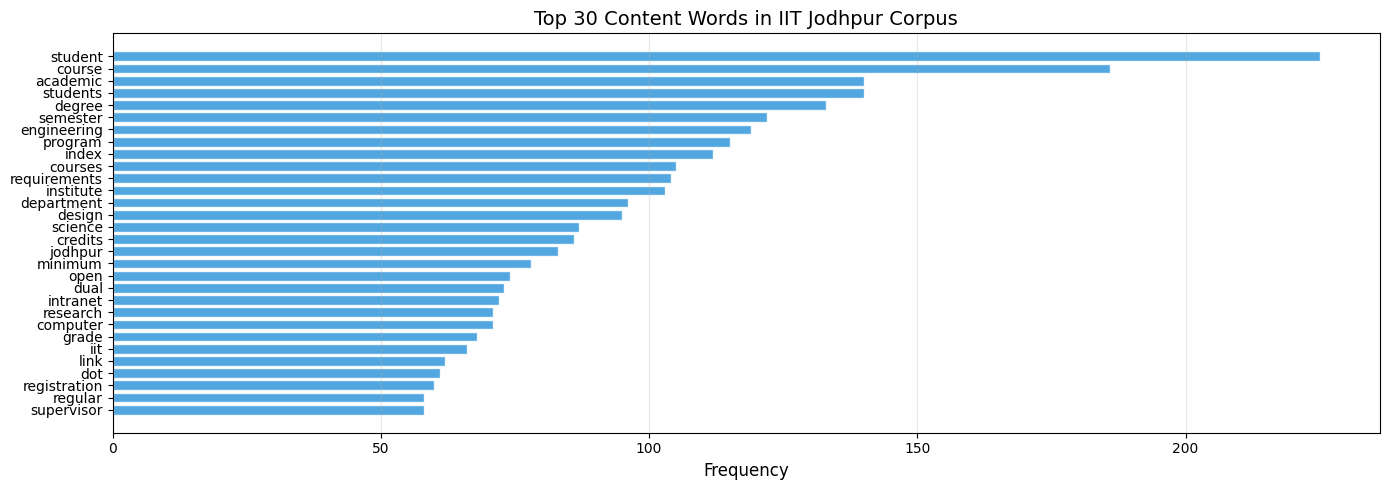

In [13]:
# Frequency distribution plot (top 30 content words)
top_words = sorted(filtered_freq.items(), key=lambda x: -x[1])[:30]
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(range(len(words)), counts, color="#3498db", alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 30 Content Words in IIT Jodhpur Corpus", fontsize=14)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

---
## Task 2: Model Training

### 2.1 Vocabulary & Data Structures for Word2Vec

In [14]:

# Build Vocabulary with Minimum Frequency Filtering

MIN_COUNT = 3  # minimum word frequency to include in vocabulary

word_counts = Counter(all_tokens)
# Filter by minimum count
vocab_words = [w for w, c in word_counts.items() if c >= MIN_COUNT]
vocab_words = sorted(vocab_words)

word2idx = {w: i for i, w in enumerate(vocab_words)}
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab_words)

print(f"Vocabulary size (min_count={MIN_COUNT}): {VOCAB_SIZE}")
print(f"Sample words: {vocab_words[:20]}")

# Convert sentences to index sequences (skip OOV words)
indexed_sentences = []
for sent in all_sentences:
    idx_sent = [word2idx[w] for w in sent if w in word2idx]
    if len(idx_sent) >= 3:
        indexed_sentences.append(idx_sent)

print(f"Indexed sentences: {len(indexed_sentences)}")

# Compute word frequencies for negative sampling distribution
word_freqs = np.zeros(VOCAB_SIZE)
for sent in indexed_sentences:
    for idx in sent:
        word_freqs[idx] += 1

# Negative sampling distribution: freq^0.75 (as in original Word2Vec paper)
neg_sampling_dist = word_freqs ** 0.75
neg_sampling_dist /= neg_sampling_dist.sum()

Vocabulary size (min_count=3): 1163
Sample words: ['ability', 'about', 'above', 'abroad', 'absence', 'abstraction', 'ac', 'academic', 'academics', 'accelerated', 'account', 'achieve', 'across', 'action', 'ad', 'adding', 'addition', 'additional', 'address', 'admission']
Indexed sentences: 1458


In [15]:

# Dataset Classes for CBOW and Skip-gram

class CBOWDataset(Dataset):
    """
    CBOW Dataset: for each target word, collect the surrounding context words.
    Input:  context words (window on both sides)
    Output: target (center) word
    """
    def __init__(self, indexed_sentences, window_size):
        self.data = []
        for sent in indexed_sentences:
            for i in range(window_size, len(sent) - window_size):
                context = sent[i - window_size : i] + sent[i + 1 : i + 1 + window_size]
                target = sent[i]
                self.data.append((context, target))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        context, target = self.data[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)


class SkipgramDataset(Dataset):
    """
    Skip-gram Dataset: for each center word, generate (center, context) pairs.
    Input:  center word
    Output: context word
    """
    def __init__(self, indexed_sentences, window_size):
        self.data = []
        for sent in indexed_sentences:
            for i in range(len(sent)):
                center = sent[i]
                # Random window size (dynamic window as in original word2vec)
                for j in range(max(0, i - window_size), min(len(sent), i + window_size + 1)):
                    if j != i:
                        self.data.append((center, sent[j]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        center, context = self.data[idx]
        return torch.tensor(center, dtype=torch.long), torch.tensor(context, dtype=torch.long)

### 2.2 Word2Vec Models — Implemented from Scratch

#### CBOW (Continuous Bag of Words)

Given context words $\{w_{t-c}, \ldots, w_{t-1}, w_{t+1}, \ldots, w_{t+c}\}$, predict the center word $w_t$.

1. Look up embeddings of all context words: $\{\mathbf{v}_{w_i}\}$
2. Compute mean context vector: $\bar{\mathbf{v}} = \frac{1}{2c}\sum_i \mathbf{v}_{w_i}$
3. Score: $s(w_t) = \mathbf{u}_{w_t}^T \bar{\mathbf{v}}$
4. Loss: Negative Sampling — maximize $\log\sigma(s(w_t))$ + $\sum_{k} \log\sigma(-s(w_k))$ for negative samples $w_k$

#### Skip-gram with Negative Sampling

Given center word $w_t$, predict context word $w_c$.

1. Look up center embedding: $\mathbf{v}_{w_t}$
2. Score: $s(w_c) = \mathbf{u}_{w_c}^T \mathbf{v}_{w_t}$
3. Loss: Negative Sampling — maximize $\log\sigma(s(w_c))$ + $\sum_{k} \log\sigma(-s(w_k))$

In [16]:

# Word2Vec Models — Scratch Implementation !

class Word2Vec_CBOW(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        # Input embeddings (context words) — initialized with small random values
        self.W_in = nn.Parameter(
            torch.randn(vocab_size, embed_dim) * (1.0 / embed_dim ** 0.5)
        )
        # Output embeddings (target words)
        self.W_out = nn.Parameter(
            torch.zeros(vocab_size, embed_dim)
        )

    def forward(self, context_indices, target_indices, neg_indices):
        # Context embeddings: (batch, 2*window, embed_dim)
        context_embeds = self.W_in[context_indices]
        # Average context: (batch, embed_dim)
        context_vec = context_embeds.mean(dim=1)

        # Positive target: (batch, embed_dim)
        target_embeds = self.W_out[target_indices]
        # Positive score: (batch,)
        pos_score = (context_vec * target_embeds).sum(dim=1)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-10)

        # Negative samples: (batch, num_neg, embed_dim)
        neg_embeds = self.W_out[neg_indices]
        # Negative scores: (batch, num_neg)
        neg_scores = torch.bmm(neg_embeds, context_vec.unsqueeze(2)).squeeze(2)
        neg_loss = -torch.log(torch.sigmoid(-neg_scores) + 1e-10).sum(dim=1)

        return (pos_loss + neg_loss).mean()

    def get_embeddings(self):
        """Return the input embeddings as the final word vectors."""
        return self.W_in.detach().cpu().numpy()


class Word2Vec_Skipgram(nn.Module):

    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        self.W_in = nn.Parameter(
            torch.randn(vocab_size, embed_dim) * (1.0 / embed_dim ** 0.5)
        )
        self.W_out = nn.Parameter(
            torch.zeros(vocab_size, embed_dim)
        )

    def forward(self, center_indices, context_indices, neg_indices):
        
        # Center embedding: (batch, embed_dim)
        center_embeds = self.W_in[center_indices]

        # Positive context: (batch, embed_dim)
        context_embeds = self.W_out[context_indices]
        pos_score = (center_embeds * context_embeds).sum(dim=1)
        pos_loss = -torch.log(torch.sigmoid(pos_score) + 1e-10)

        # Negative: (batch, num_neg, embed_dim)
        neg_embeds = self.W_out[neg_indices]
        neg_scores = torch.bmm(neg_embeds, center_embeds.unsqueeze(2)).squeeze(2)
        neg_loss = -torch.log(torch.sigmoid(-neg_scores) + 1e-10).sum(dim=1)

        return (pos_loss + neg_loss).mean()

    def get_embeddings(self):
        return self.W_in.detach().cpu().numpy()


print("Word2Vec models defined (from scratch).")
print(f"  - Word2Vec_CBOW: CBOW with Negative Sampling")
print(f"  - Word2Vec_Skipgram: Skip-gram with Negative Sampling")

Word2Vec models defined (from scratch).
  - Word2Vec_CBOW: CBOW with Negative Sampling
  - Word2Vec_Skipgram: Skip-gram with Negative Sampling


In [17]:
# Training Function

def sample_negatives(batch_size, num_neg, neg_dist, device):
    """Sample negative indices from the noise distribution."""
    neg_idx = np.random.choice(len(neg_dist), size=(batch_size, num_neg), p=neg_dist)
    return torch.tensor(neg_idx, dtype=torch.long, device=device)


def train_word2vec(
    model, dataset, neg_sampling_dist, model_type,
    num_neg=5, epochs=10, batch_size=512, lr=0.005, device="cpu",
):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                        num_workers=0, drop_last=True)

    losses = []
    model.train()

    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        num_batches = 0

        pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for batch_data in pbar:
            a, b = batch_data
            a = a.to(device)
            b = b.to(device)

            neg_idx = sample_negatives(a.size(0), num_neg, neg_sampling_dist, device)

            optimizer.zero_grad()
            if model_type == "cbow":
                loss = model(a, b, neg_idx)  # context, target, neg
            else:
                loss = model(a, b, neg_idx)  # center, context, neg

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = epoch_loss / max(num_batches, 1)
        losses.append(avg_loss)
        if epoch % 2 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} — Loss: {avg_loss:.4f}")

    return losses

### 2.3 Hyperparameter Experiments

We experiment with the following hyperparameters and report results:

| Parameter | Values Tested |
|---|---|
| Embedding dimension | 100, 200, **300** |
| Context window size | 2, **5**, 7 |
| Number of negative samples | 3, **5**, 10 |

Bold = final selected configuration. We first run a small grid search, then train the final models with `dim=300, window=5, neg=5`.

In [18]:
# Hyperparameter Grid Search (abbreviated — 3 epochs each)

SEARCH_EPOCHS = 3

configs = [
    {"embed_dim": 100, "window": 5, "num_neg": 5},
    {"embed_dim": 200, "window": 5, "num_neg": 5},
    {"embed_dim": 300, "window": 5, "num_neg": 5},
    {"embed_dim": 300, "window": 2, "num_neg": 5},
    {"embed_dim": 300, "window": 7, "num_neg": 5},
    {"embed_dim": 300, "window": 5, "num_neg": 3},
    {"embed_dim": 300, "window": 5, "num_neg": 10},
]

hp_results = []

print("Hyperparameter search (Skip-gram, 3 epochs each):")
print(f"{'Dim':>5} {'Win':>4} {'Neg':>4} {'Final Loss':>12}")
print("-" * 30)

for cfg in configs:
    ds = SkipgramDataset(indexed_sentences, cfg["window"])
    if len(ds) == 0:
        continue
    model = Word2Vec_Skipgram(VOCAB_SIZE, cfg["embed_dim"])
    losses = train_word2vec(
        model, ds, neg_sampling_dist, "skipgram",
        num_neg=cfg["num_neg"], epochs=SEARCH_EPOCHS,
        batch_size=512, lr=0.005, device=DEVICE,
    )
    final_loss = losses[-1]
    hp_results.append({**cfg, "final_loss": final_loss})
    print(f"{cfg['embed_dim']:>5} {cfg['window']:>4} {cfg['num_neg']:>4} {final_loss:>12.4f}")

print("\nSelected configuration: embed_dim=300, window=5, num_neg=5")

Hyperparameter search (Skip-gram, 3 epochs each):
  Dim  Win  Neg   Final Loss
------------------------------


  Epoch   1/3 — Loss: 2.6351


  Epoch   2/3 — Loss: 2.0940


  100    5    5       1.9461


  Epoch   1/3 — Loss: 2.5386


...

  Epoch   2/3 — Loss: 1.6239


  300    5    3       1.5126


  Epoch   1/3 — Loss: 3.2913


  Epoch   2/3 — Loss: 2.5703


  300    5   10       2.4134

Selected configuration: embed_dim=300, window=5, num_neg=5


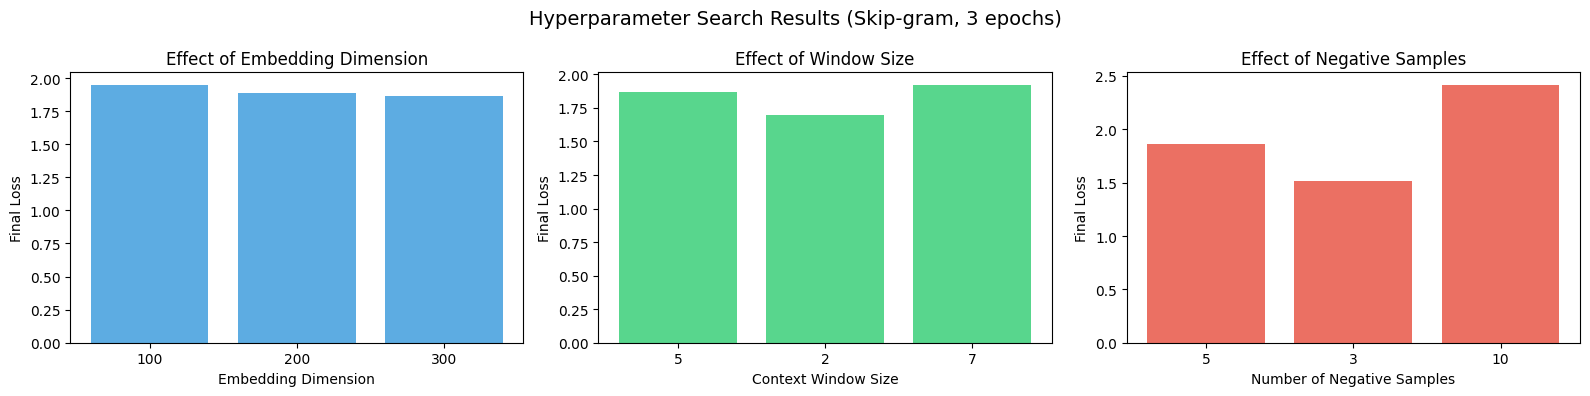

In [19]:
# Visualize hyperparameter search results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Effect of embedding dimension
dim_results = [r for r in hp_results if r["window"] == 5 and r["num_neg"] == 5]
if dim_results:
    dims = [r["embed_dim"] for r in dim_results]
    dim_losses = [r["final_loss"] for r in dim_results]
    axes[0].bar(range(len(dims)), dim_losses, tick_label=[str(d) for d in dims], color="#3498db", alpha=0.8)
    axes[0].set_xlabel("Embedding Dimension")
    axes[0].set_ylabel("Final Loss")
    axes[0].set_title("Effect of Embedding Dimension")

# Effect of window size
win_results = [r for r in hp_results if r["embed_dim"] == 300 and r["num_neg"] == 5]
if win_results:
    wins = [r["window"] for r in win_results]
    win_losses = [r["final_loss"] for r in win_results]
    axes[1].bar(range(len(wins)), win_losses, tick_label=[str(w) for w in wins], color="#2ecc71", alpha=0.8)
    axes[1].set_xlabel("Context Window Size")
    axes[1].set_ylabel("Final Loss")
    axes[1].set_title("Effect of Window Size")

# Effect of negative samples
neg_results = [r for r in hp_results if r["embed_dim"] == 300 and r["window"] == 5]
if neg_results:
    negs = [r["num_neg"] for r in neg_results]
    neg_losses = [r["final_loss"] for r in neg_results]
    axes[2].bar(range(len(negs)), neg_losses, tick_label=[str(n) for n in negs], color="#e74c3c", alpha=0.8)
    axes[2].set_xlabel("Number of Negative Samples")
    axes[2].set_ylabel("Final Loss")
    axes[2].set_title("Effect of Negative Samples")

plt.suptitle("Hyperparameter Search Results (Skip-gram, 3 epochs)", fontsize=14)
plt.tight_layout()
plt.show()

### 2.4 Train Final Models (300-dim, window=5, neg=5)

In [20]:
# Final training parameters

EMBED_DIM = 300
WINDOW_SIZE = 5
NUM_NEG = 5
EPOCHS = 15
BATCH_SIZE = 512
LEARNING_RATE = 0.005

print(f"Final Hyperparameters:")
print(f"  Embedding dimension: {EMBED_DIM}")
print(f"  Window size:         {WINDOW_SIZE}")
print(f"  Negative samples:    {NUM_NEG}")
print(f"  Epochs:              {EPOCHS}")
print(f"  Batch size:          {BATCH_SIZE}")
print(f"  Learning rate:       {LEARNING_RATE}")

Final Hyperparameters:
  Embedding dimension: 300
  Window size:         5
  Negative samples:    5
  Epochs:              15
  Batch size:          512
  Learning rate:       0.005


In [21]:

# Train CBOW (from scratch)

print("\n" + "=" * 50)
print("Training CBOW (from scratch)")
print("=" * 50)

cbow_dataset = CBOWDataset(indexed_sentences, WINDOW_SIZE)
print(f"CBOW training samples: {len(cbow_dataset):,}")

cbow_model = Word2Vec_CBOW(VOCAB_SIZE, EMBED_DIM)
print(f"CBOW parameters: {sum(p.numel() for p in cbow_model.parameters()):,}")

cbow_losses = train_word2vec(
    cbow_model, cbow_dataset, neg_sampling_dist, "cbow",
    num_neg=NUM_NEG, epochs=EPOCHS, batch_size=BATCH_SIZE,
    lr=LEARNING_RATE, device=DEVICE,
)

cbow_embeddings = cbow_model.get_embeddings()


Training CBOW (from scratch)
CBOW training samples: 9,101
CBOW parameters: 697,800


Epoch 1/15:   0%|          | 0/17 [00:00<?, ?it/s]

  Epoch   1/15 — Loss: 3.7445


  Epoch   2/15 — Loss: 2.6998


  Epoch   4/15 — Loss: 2.3551


  Epoch   6/15 — Loss: 1.9957


  Epoch   8/15 — Loss: 1.6860


  Epoch  10/15 — Loss: 1.4178


  Epoch  12/15 — Loss: 1.2066


  Epoch  14/15 — Loss: 1.0359


In [22]:

# Train Skip-gram (from scratch)

print("\n" + "=" * 50)
print("Training Skip-gram with Negative Sampling (from scratch)")
print("=" * 50)

sg_dataset = SkipgramDataset(indexed_sentences, WINDOW_SIZE)
print(f"Skip-gram training samples: {len(sg_dataset):,}")

sg_model = Word2Vec_Skipgram(VOCAB_SIZE, EMBED_DIM)
print(f"Skip-gram parameters: {sum(p.numel() for p in sg_model.parameters()):,}")

sg_losses = train_word2vec(
    sg_model, sg_dataset, neg_sampling_dist, "skipgram",
    num_neg=NUM_NEG, epochs=EPOCHS, batch_size=BATCH_SIZE,
    lr=LEARNING_RATE, device=DEVICE,
)

sg_embeddings = sg_model.get_embeddings()


Training Skip-gram with Negative Sampling (from scratch)
Skip-gram training samples: 167,662
Skip-gram parameters: 697,800


  Epoch   1/15 — Loss: 2.4837


  Epoch   2/15 — Loss: 1.9945


  Epoch   4/15 — Loss: 1.8030


  Epoch   6/15 — Loss: 1.7478


  Epoch   8/15 — Loss: 1.7273


  Epoch  10/15 — Loss: 1.7166


  Epoch  12/15 — Loss: 1.7147


  Epoch  14/15 — Loss: 1.7069


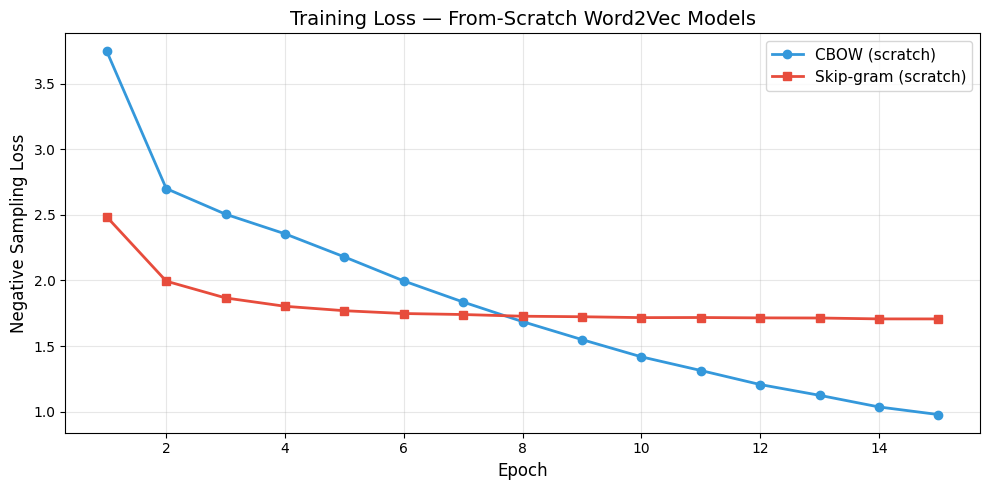

In [23]:
# Plot training losses
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, EPOCHS + 1), cbow_losses, label="CBOW (scratch)", color="#3498db", linewidth=2, marker="o")
ax.plot(range(1, EPOCHS + 1), sg_losses, label="Skip-gram (scratch)", color="#e74c3c", linewidth=2, marker="s")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Negative Sampling Loss", fontsize=12)
ax.set_title("Training Loss — From-Scratch Word2Vec Models", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 Gensim Baseline Models (for Comparison)

In [24]:

# Train Gensim Word2Vec Models for Comparison

# CBOW (sg=0)
print("Training Gensim CBOW...")
gensim_cbow = GensimWord2Vec(
    sentences=all_sentences,
    vector_size=EMBED_DIM,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    sg=0,  # CBOW
    negative=NUM_NEG,
    epochs=EPOCHS,
    seed=SEED,
    workers=1,
)
print(f"  Vocabulary: {len(gensim_cbow.wv)}")

# Skip-gram (sg=1)
print("Training Gensim Skip-gram...")
gensim_sg = GensimWord2Vec(
    sentences=all_sentences,
    vector_size=EMBED_DIM,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    sg=1,  # Skip-gram
    negative=NUM_NEG,
    epochs=EPOCHS,
    seed=SEED,
    workers=1,
)
print(f"  Vocabulary: {len(gensim_sg.wv)}")
print("\nDone! Both Gensim models trained.")

Training Gensim CBOW...
  Vocabulary: 1163
Training Gensim Skip-gram...
  Vocabulary: 1163

Done! Both Gensim models trained.


### 2.6 Print Full 300-Dimensional Embedding Vector

In [25]:

# Print full 300-dimensional vector for a word

DEMO_WORD = "research"

if DEMO_WORD in word2idx:
    idx = word2idx[DEMO_WORD]
    vec = sg_embeddings[idx]  # from our scratch skip-gram

    print(f"Full {EMBED_DIM}-dimensional embedding for '{DEMO_WORD}' (Skip-gram, from scratch):")
    print(f"Shape: {vec.shape}")
    print(f"\nVector:")
    # Print in a readable format, 10 values per line
    for i in range(0, len(vec), 10):
        chunk = vec[i:i+10]
        formatted = ", ".join(f"{v:>9.6f}" for v in chunk)
        print(f"  [{i:3d}-{min(i+9, len(vec)-1):3d}]: {formatted}")

    print(f"\nL2 Norm: {np.linalg.norm(vec):.4f}")
else:
    print(f"'{DEMO_WORD}' not in vocabulary. Try one of: {vocab_words[:10]}")

Full 300-dimensional embedding for 'research' (Skip-gram, from scratch):
Shape: (300,)

Vector:
  [  0-  9]:  0.065433,  0.034220, -0.013918, -0.102330,  0.106308,  0.754604, -0.068694,  0.230153, -0.252178,  0.429872
  [ 10- 19]: -0.280617, -0.344774, -0.144340, -0.310956,  0.065723,  0.321372, -0.183525, -0.037699,  0.049203, -0.161300
  [ 20- 29]:  0.289650,  0.049186, -0.013112, -0.244345,  0.043678,  0.024224,  0.241841, -0.066416, -0.039180, -0.035622
  [ 30- 39]:  0.468879, -0.412149,  0.016446,  0.097034,  0.051922, -0.002763,  0.602463,  0.357763,  0.178237,  0.363331
  [ 40- 49]:  0.208577, -0.216596,  0.465566,  0.168893,  0.101740, -0.274760,  0.338600,  0.129318, -0.225241, -0.184224
  [ 50- 59]: -0.177568, -0.211134,  0.043992, -0.036893, -0.152232, -0.087096, -0.046272, -0.125216,  0.161480,  0.104765
  [ 60- 69]: -0.089615,  0.169245, -0.107555,  0.013202,  0.299455,  0.088262,  0.342604,  0.193427, -0.174463,  0.158099
  [ 70- 79]: -0.244839, -0.352942, -0.146457,  0.0

---
## Task 3: Semantic Analysis

### 3.1 Nearest Neighbors using Cosine Similarity

In [26]:

# Utility Functions for Semantic Analysis

def get_nearest_neighbors(word, embeddings, word2idx, idx2word, top_k=5):
    """
    Find top-k nearest neighbors of a word using cosine similarity.

    Returns list of (word, similarity) tuples.
    """
    if word not in word2idx:
        return []

    idx = word2idx[word]
    word_vec = embeddings[idx].reshape(1, -1)

    # Cosine similarity with all words
    similarities = cosine_similarity(word_vec, embeddings)[0]

    # Sort descending, skip the word itself (index 0 in sorted = the word itself)
    top_indices = similarities.argsort()[::-1][1 : top_k + 1]

    return [(idx2word[i], similarities[i]) for i in top_indices]


def analogy(a, b, c, embeddings, word2idx, idx2word, top_k=5):
    """
    Solve analogy: a:b :: c:?
    vec(?) ≈ vec(b) - vec(a) + vec(c)

    Returns top-k candidates.
    """
    if any(w not in word2idx for w in [a, b, c]):
        missing = [w for w in [a, b, c] if w not in word2idx]
        return [], missing

    vec_a = embeddings[word2idx[a]]
    vec_b = embeddings[word2idx[b]]
    vec_c = embeddings[word2idx[c]]

    target_vec = (vec_b - vec_a + vec_c).reshape(1, -1)
    similarities = cosine_similarity(target_vec, embeddings)[0]

    # Exclude input words
    exclude = {word2idx[a], word2idx[b], word2idx[c]}
    candidates = []
    for i in similarities.argsort()[::-1]:
        if i not in exclude:
            candidates.append((idx2word[i], similarities[i]))
        if len(candidates) >= top_k:
            break

    return candidates, []

In [34]:
# Top 4 Nearest Neighbors for Target Words

TARGET_WORDS = ["research", "student", "phd", "exam"]

# Build a mapping for all four models
model_embeddings = {
    "CBOW (scratch)": cbow_embeddings,
    "Skip-gram (scratch)": sg_embeddings,
}

# Add gensim models (need to align vocabulary)
# Build gensim embedding matrix aligned with our word2idx
def build_gensim_matrix(gensim_model, word2idx, embed_dim):
    matrix = np.zeros((len(word2idx), embed_dim))
    for word, idx in word2idx.items():
        if word in gensim_model.wv:
            matrix[idx] = gensim_model.wv[word]
    return matrix

gensim_cbow_emb = build_gensim_matrix(gensim_cbow, word2idx, EMBED_DIM)
gensim_sg_emb = build_gensim_matrix(gensim_sg, word2idx, EMBED_DIM)

model_embeddings["CBOW (Gensim)"] = gensim_cbow_emb
model_embeddings["Skip-gram (Gensim)"] = gensim_sg_emb

print("Top 4 Nearest Neighbors (Cosine Similarity)")
print("=" * 80)

for word in TARGET_WORDS:
    print(f"\n  Query: '{word}'")
    print(f"  {'Model':<25} {'Neighbor 1':<14} {'Neighbor 2':<14} {'Neighbor 3':<14} {'Neighbor 4':<14} ")
    print(f"  {'-'*95}")

    for model_name, emb in model_embeddings.items():
        neighbors = get_nearest_neighbors(word, emb, word2idx, idx2word, top_k=5)
        if neighbors:
            nbr_strs = [f"{w} ({s:.3f})" for w, s in neighbors]
            print(f"  {model_name:<25} {'  '.join(nbr_strs)}")
        else:
            print(f"  {model_name:<25} [word not in vocabulary]")

Top 4 Nearest Neighbors (Cosine Similarity)

  Query: 'research'
  Model                     Neighbor 1     Neighbor 2     Neighbor 3     Neighbor 4     
  -----------------------------------------------------------------------------------------------
  CBOW (scratch)            industrial (0.567)  faculty (0.563)  sota (0.561)  excellence (0.556)  pre (0.555)
  Skip-gram (scratch)       proposal (0.462)  defense (0.377)  collaborative (0.375)  synopsis (0.360)  craft (0.356)
  CBOW (Gensim)             both (0.998)  defense (0.998)  consultation (0.998)  outside (0.998)  criteria (0.998)
  Skip-gram (Gensim)        proposal (0.838)  experience (0.810)  work (0.799)  members (0.796)  teaching (0.789)

  Query: 'student'
  Model                     Neighbor 1     Neighbor 2     Neighbor 3     Neighbor 4     
  -----------------------------------------------------------------------------------------------
  CBOW (scratch)            advertisement (0.577)  thesis (0.559)  follows (0.556) 

### 3.2 Analogy Experiments

In [28]:
# Analogy Experiments

ANALOGIES = [
    # UG : BTech :: PG : ?
    ("ug", "btech", "pg", "Expected: mtech"),
    # student : learn :: professor : ?
    ("student", "learn", "professor", "Expected: teach/research"),
    # btech : undergraduate :: phd : ?
    ("btech", "undergraduate", "phd", "Expected: doctoral/postgraduate"),
    # jodhpur : rajasthan :: delhi : ?
    ("jodhpur", "rajasthan", "delhi", "Expected: india/national"),
]

print("Analogy Experiments: a : b :: c : ?")
print("(vec(?) ≈ vec(b) - vec(a) + vec(c))")
print("=" * 80)

for a, b, c, expected in ANALOGIES:
    print(f"\n  {a} : {b} :: {c} : ?  [{expected}]")
    print(f"  {'Model':<25} {'Top 5 candidates'}")
    print(f"  {'-'*60}")

    for model_name, emb in model_embeddings.items():
        results, missing = analogy(a, b, c, emb, word2idx, idx2word, top_k=5)
        if missing:
            print(f"  {model_name:<25} [missing words: {missing}]")
        elif results:
            res_str = ", ".join(f"{w} ({s:.3f})" for w, s in results)
            print(f"  {model_name:<25} {res_str}")
        else:
            print(f"  {model_name:<25} [no results]")

Analogy Experiments: a : b :: c : ?
(vec(?) ≈ vec(b) - vec(a) + vec(c))

  ug : btech :: pg : ?  [Expected: mtech]
  Model                     Top 5 candidates
  ------------------------------------------------------------
  CBOW (scratch)            [missing words: ['btech']]
  Skip-gram (scratch)       [missing words: ['btech']]
  CBOW (Gensim)             [missing words: ['btech']]
  Skip-gram (Gensim)        [missing words: ['btech']]

  student : learn :: professor : ?  [Expected: teach/research]
  Model                     Top 5 candidates
  ------------------------------------------------------------
  CBOW (scratch)            assistant (0.677), cryptography (0.651), ml (0.589), email (0.571), visualization (0.543)
  Skip-gram (scratch)       assistant (0.459), cryptography (0.451), maybe (0.451), complexity (0.441), trusted (0.419)
  CBOW (Gensim)             dot (0.839), iitj (0.839), ac (0.814), call (0.812), email (0.810)
  Skip-gram (Gensim)        assistant (0.901), sharm

---
## Task 4: Visualization

### 4.1 t-SNE and PCA Projections

We select word clusters from the following semantic categories:
- **Academic programs:** btech, mtech, phd, mba, msc, undergraduate, postgraduate, doctoral
- **Departments:** engineering, science, computer, electrical, mechanical, chemistry, physics, mathematics
- **Academic life:** student, faculty, professor, semester, exam, grade, credit, thesis
- **Campus & institute:** campus, jodhpur, institute, iit, hostel, library, laboratory
- **Research:** research, publication, project, innovation, technology, development

In [29]:
# Select Words for Visualization (filter to those in vocabulary)

cluster_words = {
    "Academic Programs": ["btech", "mtech", "phd", "mba", "msc", "undergraduate",
                          "postgraduate", "doctoral", "degree", "diploma"],
    "Departments": ["engineering", "science", "computer", "electrical", "mechanical",
                    "chemistry", "physics", "mathematics", "civil", "humanities"],
    "Academic Life": ["student", "faculty", "professor", "semester", "exam",
                      "grade", "credit", "thesis", "course", "lecture"],
    "Campus": ["campus", "jodhpur", "institute", "iit", "hostel",
               "library", "laboratory", "department", "building", "facilities"],
    "Research": ["research", "publication", "project", "innovation", "technology",
                 "development", "analysis", "design", "computational", "data"],
}

# Filter to words actually in our vocabulary
viz_words = []
viz_labels = []
viz_colors = []
color_map = {"Academic Programs": "#e74c3c", "Departments": "#2ecc71",
             "Academic Life": "#3498db", "Campus": "#9b59b6", "Research": "#f39c12"}

for category, words in cluster_words.items():
    for w in words:
        if w in word2idx:
            viz_words.append(w)
            viz_labels.append(category)
            viz_colors.append(color_map[category])

print(f"Words selected for visualization: {len(viz_words)}")
for cat in cluster_words:
    present = [w for w in cluster_words[cat] if w in word2idx]
    missing = [w for w in cluster_words[cat] if w not in word2idx]
    print(f"  {cat}: {len(present)} words")
    if missing:
        print(f"    (not in vocab: {missing})")

Words selected for visualization: 42
  Academic Programs: 5 words
    (not in vocab: ['btech', 'mba', 'msc', 'doctoral', 'diploma'])
  Departments: 10 words
  Academic Life: 9 words
    (not in vocab: ['exam'])
  Campus: 9 words
    (not in vocab: ['hostel'])
  Research: 9 words
    (not in vocab: ['publication'])


In [30]:
# Visualization Function


def plot_embeddings_2d(embeddings, word2idx, viz_words, viz_labels, viz_colors,
                       method="tsne", title="", ax=None):
    """
    Project selected word embeddings to 2D using PCA or t-SNE and plot.
    """
    # Extract vectors for selected words
    indices = [word2idx[w] for w in viz_words]
    vecs = embeddings[indices]

    # Reduce to 2D
    if method == "tsne":
        perplexity = min(30, len(viz_words) - 1)
        reducer = TSNE(n_components=2, random_state=SEED, perplexity=perplexity,
                       max_iter=1000, learning_rate="auto", init="pca")
    else:
        reducer = PCA(n_components=2, random_state=SEED)

    coords = reducer.fit_transform(vecs)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 9))

    # Plot by category
    categories = list(set(viz_labels))
    for cat in categories:
        mask = [i for i, l in enumerate(viz_labels) if l == cat]
        cat_color = viz_colors[mask[0]]
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=cat_color, label=cat, s=80, alpha=0.8, edgecolors="white", linewidth=0.5,
        )
        for i in mask:
            ax.annotate(
                viz_words[i],
                (coords[i, 0], coords[i, 1]),
                fontsize=9, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points",
            )

    ax.legend(fontsize=10, loc="best")
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.2)
    return ax

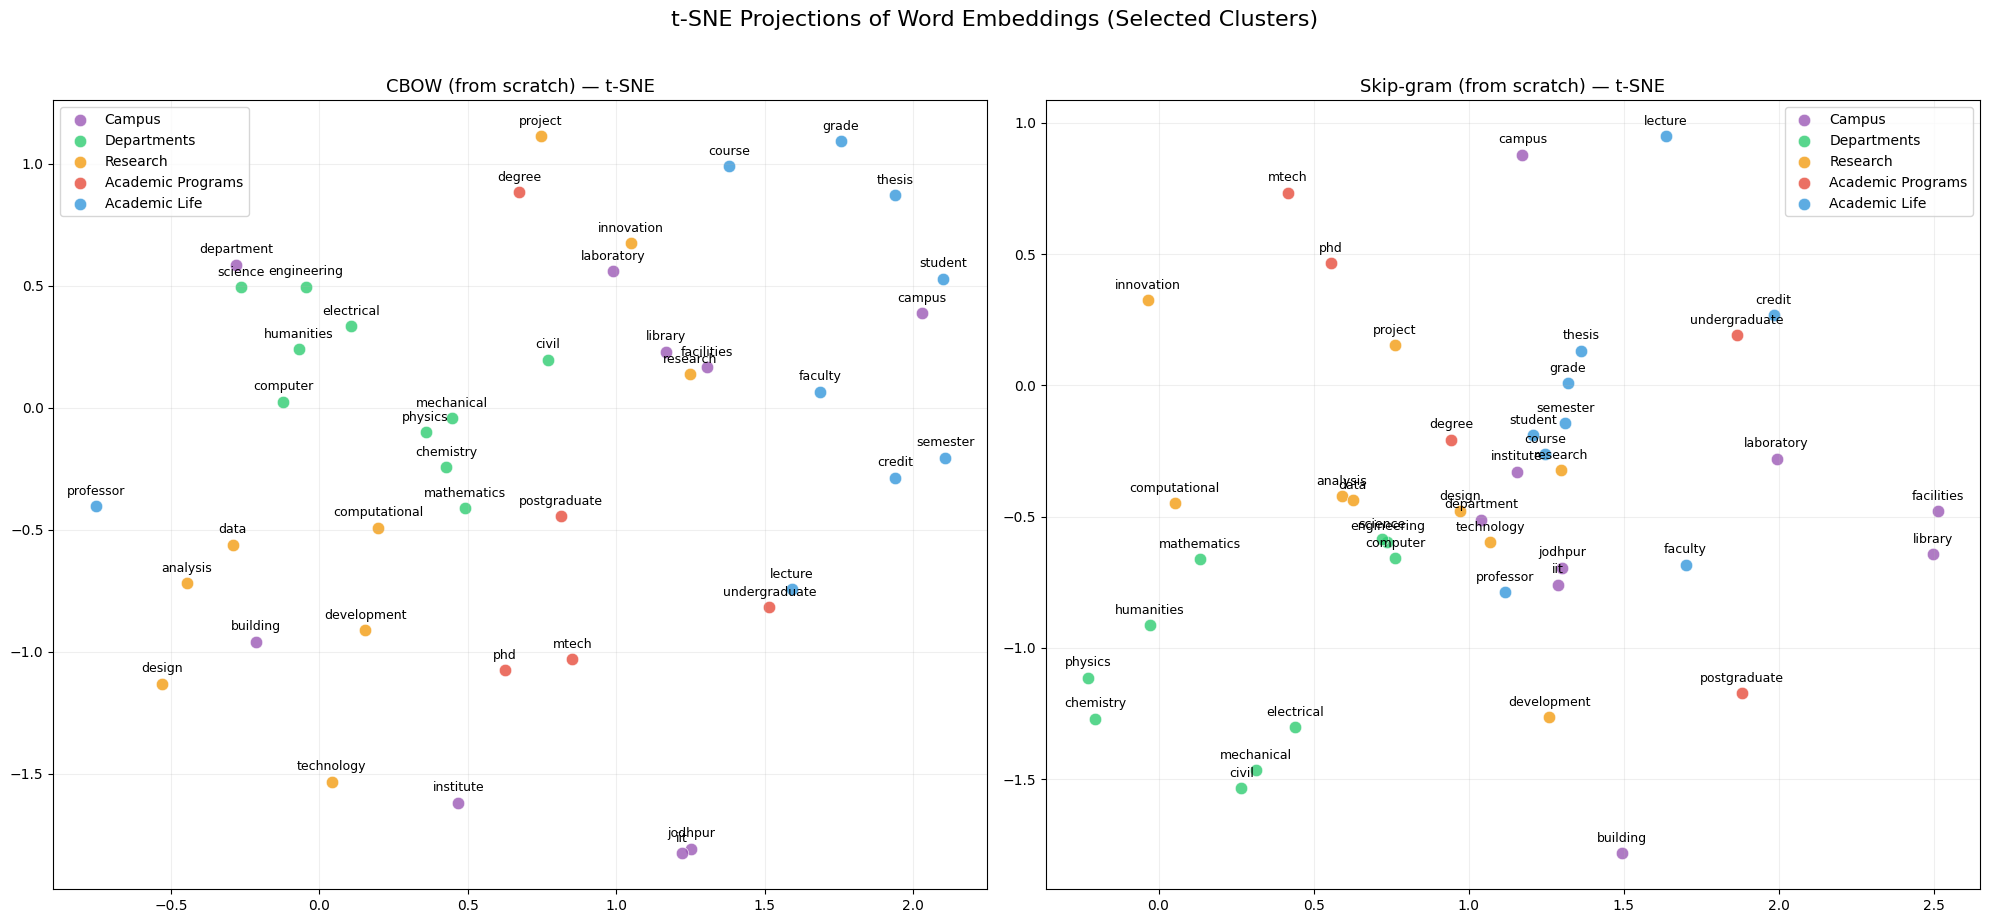

In [31]:

# t-SNE Visualization: CBOW vs Skip-gram


fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_embeddings_2d(
    cbow_embeddings, word2idx, viz_words, viz_labels, viz_colors,
    method="tsne", title="CBOW (from scratch) — t-SNE", ax=axes[0],
)
plot_embeddings_2d(
    sg_embeddings, word2idx, viz_words, viz_labels, viz_colors,
    method="tsne", title="Skip-gram (from scratch) — t-SNE", ax=axes[1],
)

plt.suptitle("t-SNE Projections of Word Embeddings (Selected Clusters)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

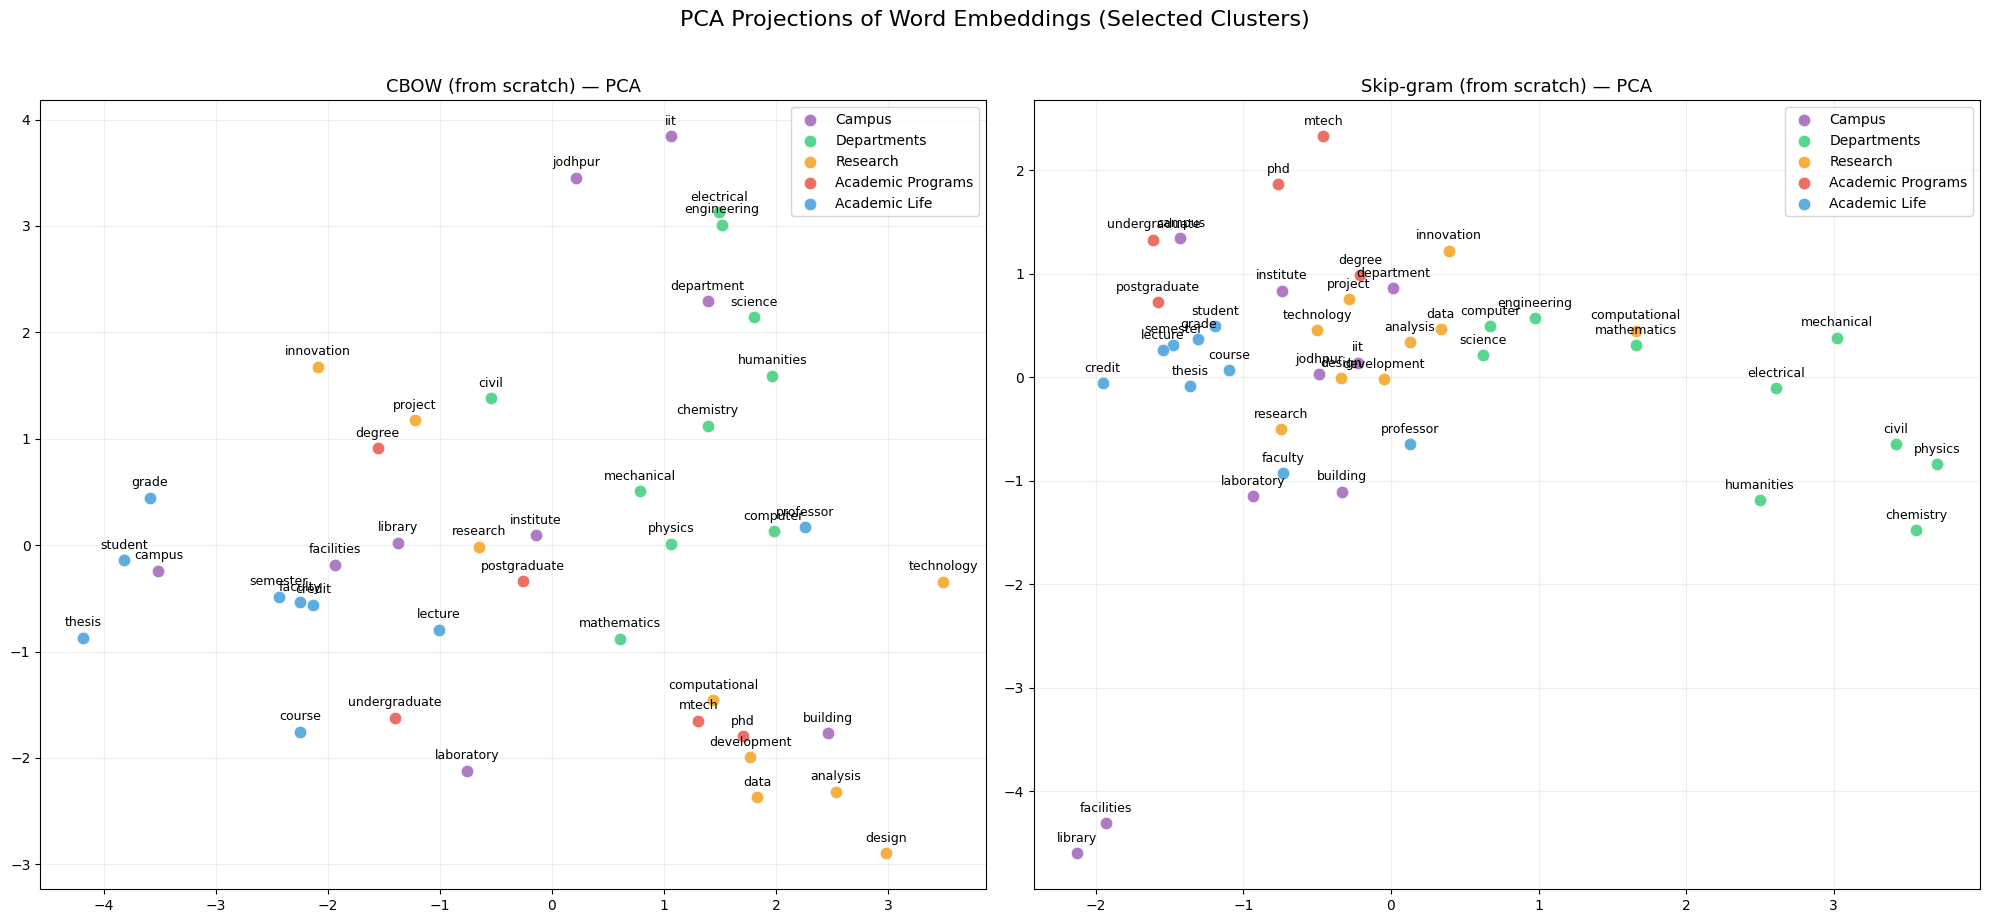

In [32]:

# PCA Visualization: CBOW vs Skip-gram (from scratch)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_embeddings_2d(
    cbow_embeddings, word2idx, viz_words, viz_labels, viz_colors,
    method="pca", title="CBOW (from scratch) — PCA", ax=axes[0],
)
plot_embeddings_2d(
    sg_embeddings, word2idx, viz_words, viz_labels, viz_colors,
    method="pca", title="Skip-gram (from scratch) — PCA", ax=axes[1],
)

plt.suptitle("PCA Projections of Word Embeddings (Selected Clusters)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

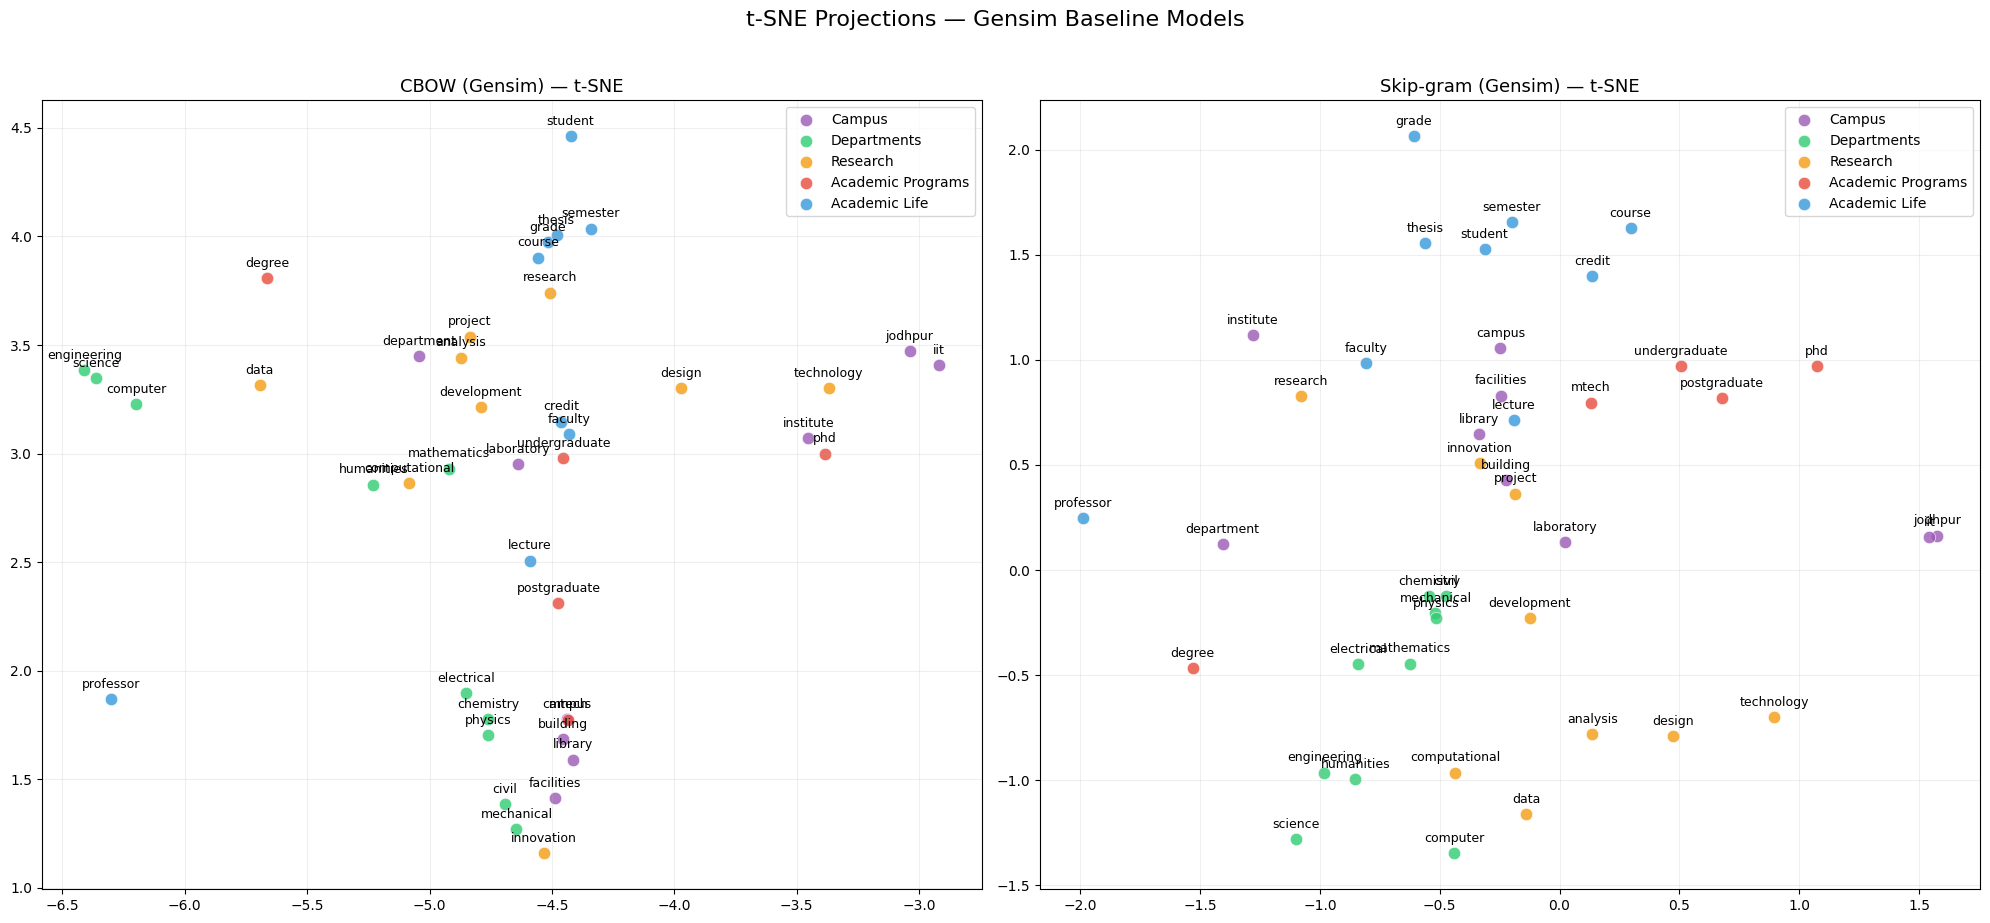

In [33]:
# t-SNE: Gensim models for comparison

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

plot_embeddings_2d(
    gensim_cbow_emb, word2idx, viz_words, viz_labels, viz_colors,
    method="tsne", title="CBOW (Gensim) — t-SNE", ax=axes[0],
)
plot_embeddings_2d(
    gensim_sg_emb, word2idx, viz_words, viz_labels, viz_colors,
    method="tsne", title="Skip-gram (Gensim) — t-SNE", ax=axes[1],
)

plt.suptitle("t-SNE Projections — Gensim Baseline Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()